In [1]:
# import libraries is requires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('HR_comma_sep.csv')

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [3]:
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
data['salary'].value_counts()

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

In [6]:
data['left'].value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

In [8]:
data.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [14]:
data['average_montly_hours'].value_counts()

average_montly_hours
135    153
156    153
149    148
151    147
160    136
      ... 
297      7
288      6
299      6
303      6
96       6
Name: count, Length: 215, dtype: int64

In [12]:
data['average_montly_hours'].duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
14994     True
14995     True
14996     True
14997     True
14998     True
Name: average_montly_hours, Length: 14999, dtype: bool

In [7]:
# Perform data quality checks by checking for missing values, if any.
data.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

### Data types present

The dataset (`HR_comma_sep.csv`) has 14,999 rows × 10 columns, with no missing values.

**Numeric (continuous) — `float64`**
| Column | Description |
|---|---|
| `satisfaction_level` | Employee satisfaction score (0–1) |
| `last_evaluation` | Last performance evaluation score (0–1) |

**Numeric (discrete / count or binary) — `int64`**
| Column | Description |
|---|---|
| `number_project` | Number of projects assigned |
| `average_montly_hours` | Average monthly working hours |
| `time_spend_company` | Years spent at the company |
| `Work_accident` | Binary (0/1) — had a workplace accident |
| `left` | Binary (0/1) — target variable, whether employee left |
| `promotion_last_5years` | Binary (0/1) — promoted in last 5 years |

**Categorical — `object`/`str`**
| Column | Description |
|---|---|
| `sales` | Department (10 categories: sales, accounting, hr, technical, support, management, IT, product_mng, marketing, RandD) |
| `salary` | Salary level (3 categories: low, medium, high — ordinal) |

**Summary:** 8 numeric columns (2 continuous + 6 discrete, 3 of which are binary flags) and 2 categori

In [25]:
# Understand what factors contributed most to employee turnover at EDA.
numeric_features = data.select_dtypes(include=[np.number]).columns
numeric_features


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years'],
      dtype='str')

In [26]:
str_features = data.select_dtypes(include=['object','str']).columns
str_features

Index(['sales', 'salary'], dtype='str')

                       satisfaction_level  last_evaluation  number_project  \
satisfaction_level               1.000000         0.105021       -0.142970   
last_evaluation                  0.105021         1.000000        0.349333   
number_project                  -0.142970         0.349333        1.000000   
average_montly_hours            -0.020048         0.339742        0.417211   
time_spend_company              -0.100866         0.131591        0.196786   
Work_accident                    0.058697        -0.007104       -0.004741   
left                            -0.388375         0.006567        0.023787   
promotion_last_5years            0.025605        -0.008684       -0.006064   

                       average_montly_hours  time_spend_company  \
satisfaction_level                -0.020048           -0.100866   
last_evaluation                    0.339742            0.131591   
number_project                     0.417211            0.196786   
average_montly_hours         

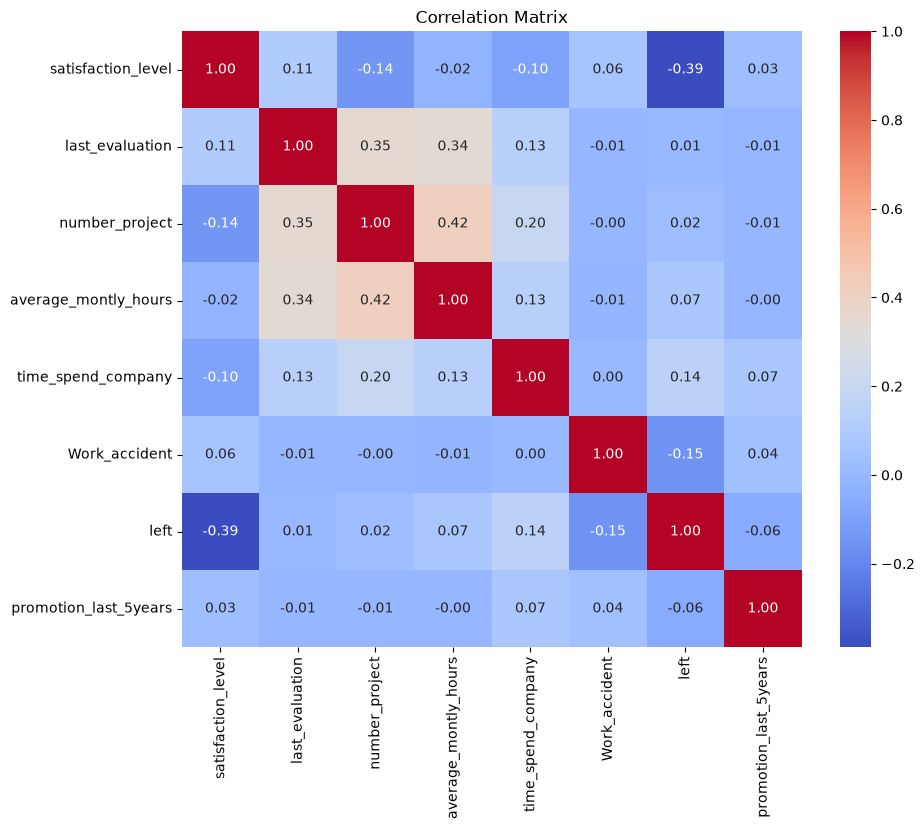

In [30]:
# Draw a heatmap of the correlation matrix between all numerical features or columns in the data.
print(data[numeric_features].corr())
plt.figure(figsize=(10, 8))
sns.heatmap(data[numeric_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Interpreting the correlation matrix

`data[numeric_features].corr()` computes the pairwise **Pearson correlation coefficient** (range -1 to +1) between every numeric column. A value near **+1** means the two variables move together, near **-1** means they move oppositely, and near **0** means little to no linear relationship.

**Correlation with the target (`left`), strongest first:**
| Feature | Correlation with `left` | Interpretation |
|---|---|---|
| `satisfaction_level` | **-0.39** | Strongest driver — lower satisfaction is strongly associated with employees leaving |
| `Work_accident` | -0.15 | Employees who had a workplace accident are (slightly) less likely to leave |
| `time_spend_company` | +0.14 | Employees who have stayed longer are somewhat more likely to leave |
| `average_montly_hours` | +0.07 | Weak positive relationship — more hours, slightly more likely to leave |
| `promotion_last_5years` | -0.06 | Weak — recently promoted employees are slightly less likely to leave |
| `number_project` | +0.02 | Negligible |
| `last_evaluation` | +0.01 | Negligible |

**Other notable relationships between features (not the target):**
- `number_project` & `average_montly_hours` (**+0.42**) — employees on more projects tend to work more hours.
- `last_evaluation` & `number_project` (**+0.35**) and `last_evaluation` & `average_montly_hours` (**+0.34**) — better-evaluated employees tend to handle more projects and work longer hours.

**Takeaway:** `satisfaction_level` is by far the most important numeric predictor of turnover i

In [42]:
# satisfaction_level ,last_evaluation, average_montly_hours
# Most common values, Outliers,Skewness, Normal distribution, Multiple groups of employees

data[['satisfaction_level','last_evaluation','average_montly_hours']].describe()

,satisfaction_level,last_evaluation,average_montly_hours
count,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,201.050337
std,0.248631,0.171169,49.943099
min,0.090000,0.360000,96.000000
25%,0.440000,0.560000,156.000000
50%,0.640000,0.720000,200.000000
75%,0.820000,0.870000,245.000000
max,1.000000,1.000000,310.000000


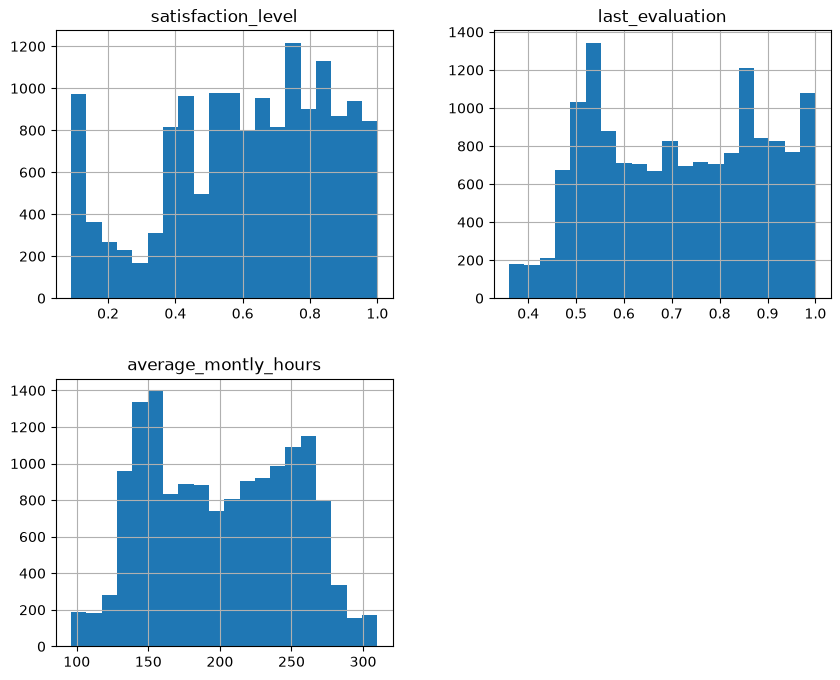

In [43]:
# Histogram, KDE plot, Distribution, Mean, Median, Skewness, Outliers

data[['satisfaction_level','last_evaluation','average_montly_hours']].hist(bins=20, figsize=(10, 8))
plt.show()

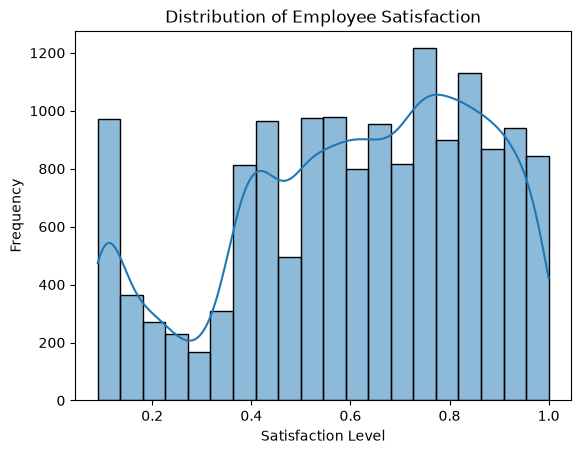

In [38]:
# Draw the distribution plot
# Employee Satisfaction (use column satisfaction_level)
sns.histplot(data['satisfaction_level'], kde=True, bins=20)
plt.xlabel('Satisfaction Level')
plt.ylabel('Frequency')
plt.title('Distribution of Employee Satisfaction')
plt.show()

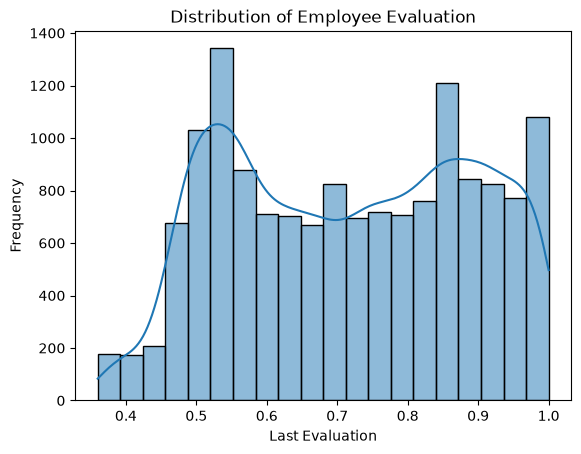

In [39]:
# Employee Evaluation (use column last_evaluation)
sns.histplot(data['last_evaluation'], kde=True, bins=20)
plt.xlabel('Last Evaluation')
plt.ylabel('Frequency')
plt.title('Distribution of Employee Evaluation')
plt.show()

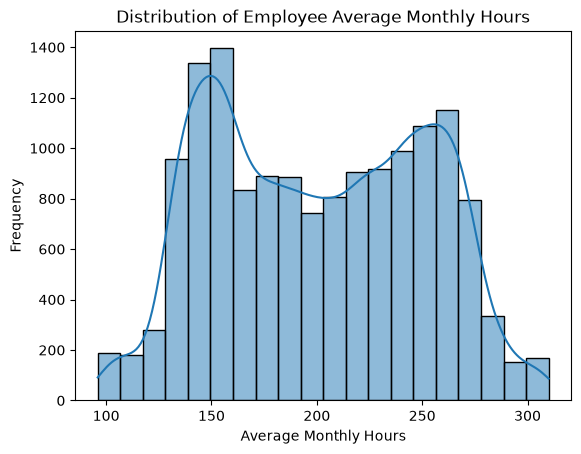

In [40]:
# Employee Average Monthly Hours (use column average_montly_hours)
sns.histplot(data['average_montly_hours'], kde=True, bins=20)
plt.xlabel('Average Monthly Hours')
plt.ylabel('Frequency')
plt.title('Distribution of Employee Average Monthly Hours')
plt.show()

### Distribution analysis — `satisfaction_level`, `last_evaluation`, `average_montly_hours`

| Feature | Skewness | Mean vs Median | Shape / Outliers |
|---|---|---|---|
| `satisfaction_level` | -0.48 (mildly left-skewed) | 0.61 vs 0.64 | **Multi-modal** — clear clusters near ~0.1 (very dissatisfied), ~0.4, and ~0.7–1.0 (highly satisfied), with a dip around 0.2–0.3. Not a single "normal" shape — this signals multiple distinct employee segments rather than outliers. |
| `last_evaluation` | -0.03 (~symmetric) | 0.72 vs 0.72 | Roughly **bimodal**, humps around 0.55 and 0.85–1.0. Range 0.36–1.0, no extreme outliers. |
| `average_montly_hours` | 0.05 (~symmetric) | 201 vs 200 | Roughly **bimodal**, humps around 150–160 hrs (underworked) and 250–260 hrs (overworked). Range 96–310, no extreme outliers. |

**Inference:** none of the three features follows a simple unimodal/normal distribution — each shows two or three sub-groups of employees (e.g., low vs. high satisfaction, under- vs. over-worked). This hints that employee behavior/turnover is driven by distinct segments rather than a single continuous trend, which the project-count analysis below confirms.

number_project
4    4365
3    4055
5    2761
2    2388
6    1174
7     256
Name: count, dtype: int64


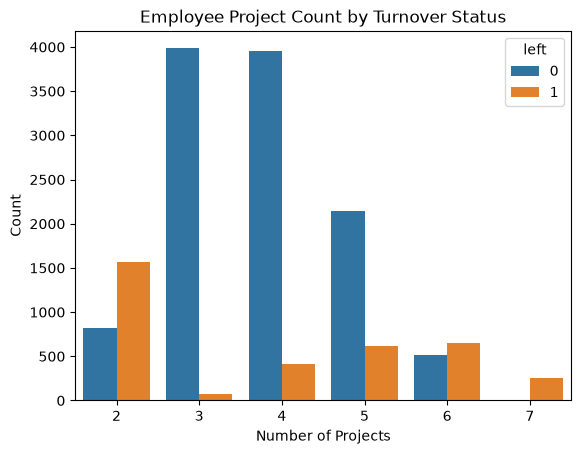

In [45]:
# Draw the bar plot of the employee project count of both employees who left and stayed in the organization
# (use column number_project and hue column left), and give your inferences from the plot.
print(data['number_project'].value_counts())
sns.countplot(data=data, x='number_project', hue='left')
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.title('Employee Project Count by Turnover Status')
plt.show()

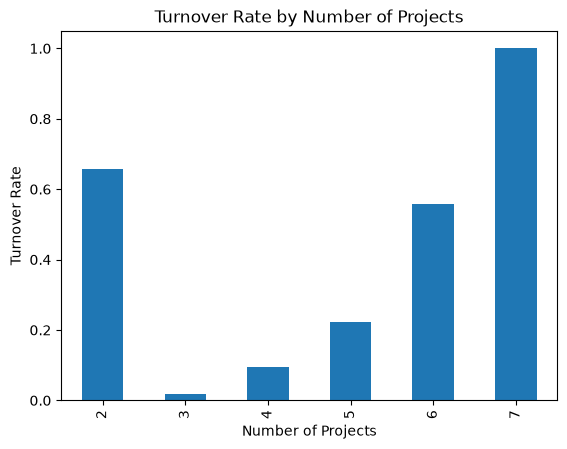

In [55]:
# Do employees with many projects leave more?
# Do employees with fewer projects leave more?
# Is there an optimal workload?
# Does too much workload increase turnover?

data.groupby('number_project')['left'].mean().plot(kind='bar')
plt.xlabel('Number of Projects')
plt.ylabel('Turnover Rate')
plt.title('Turnover Rate by Number of Projects')
plt.show()


### Inference — turnover rate by `number_project`

| Projects | Employees | Turnover rate |
|---|---|---|
| 2 | 2,388 | **65.6%** |
| 3 | 4,055 | 1.8% |
| 4 | 4,365 | 9.4% |
| 5 | 2,761 | 22.2% |
| 6 | 1,174 | 55.8% |
| 7 | 256 | **100%** |

This is a **U-shaped ("both ends") relationship**, not a simple linear one:

- **Do employees with many projects leave more?** Yes — turnover rises sharply from 4 → 7 projects, and every employee with 7 projects left. Overload/burnout drives them out.
- **Do employees with fewer projects leave more?** Yes, at the low end too — employees with only 2 projects have a 65.6% turnover rate, likely disengaged/underutilized employees.
- **Is there an optimal workload?** Yes — **3–4 projects** has by far the lowest turnover (1.8%–9.4%), the "sweet spot" of workload.
- **Does too much workload increase turnover?** Yes, strongly — turnover climbs from 9.4% (4 projects) to 100% (7 projects).

**Takeaway:** turnover is highest at both extremes of workload (too little or too much), and lowest in the middle (3–4 projects) — workload should be managed to keep employees in that mid-range rather than assuming "more projects = more retention" or "fewer projects = more retention."

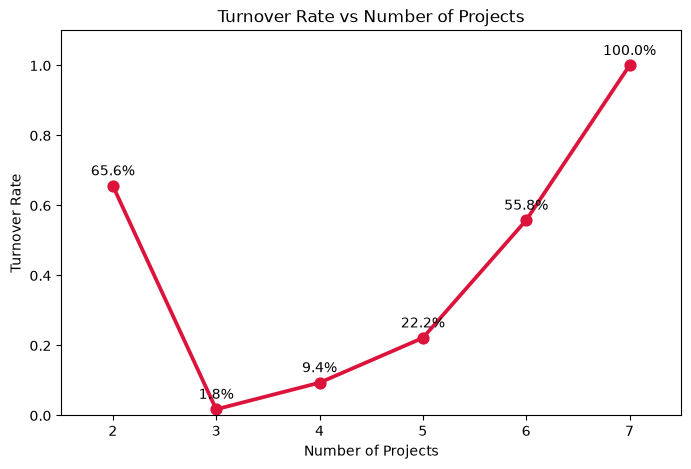

In [56]:
# Visualize the U-shaped relationship between number_project and turnover rate
turnover_rate = data.groupby('number_project')['left'].mean()

plt.figure(figsize=(8, 5))
sns.pointplot(x=turnover_rate.index, y=turnover_rate.values, color='crimson')
for i, v in enumerate(turnover_rate.values):
    plt.text(i, v + 0.03, f'{v:.1%}', ha='center')
plt.xlabel('Number of Projects')
plt.ylabel('Turnover Rate')
plt.title('Turnover Rate vs Number of Projects')
plt.ylim(0, 1.1)
plt.show()